In [1]:
import os
import random
import spacy
import json
from tqdm import tqdm
from dotenv import load_dotenv
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from elasticsearch.helpers import scan

from utils import create_fragments_index

random.seed(420)
load_dotenv()
ES_HOST = os.getenv("ES_HOST", "http://localhost:9200")
INDEX_NAME = os.getenv("INDEX_NAME")
FRAGMENT_INDEX_NAME = f"{os.getenv('INDEX_NAME')}_fragments"
es_client = Elasticsearch('http://localhost:9200')

embed_model = SentenceTransformer("all-MiniLM-L6-v2", device=os.getenv("MODEL_DEVICE", "cpu"))

/home/zbrzeznyg/miniconda3/envs/masters/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Creating whole fragments index

In [2]:
# create_fragments_index(
#     es_client=es_client,
#     dataset_path="../data/putin_complete.json",
#     n_speeches=10000
# )

### Create sample fragment indices for tests

In [3]:
# For testing purposes, I limit the number of speeches to 100
CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME = f"{os.getenv('INDEX_NAME')}_fragments_sample_chunk_3"
SAMPLE_FRAGMENTS_INDEX_NAME = f"{os.getenv('INDEX_NAME')}_fragments_sample"

es_client.indices.delete(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
es_client.indices.create(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)

es_client.indices.delete(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
es_client.indices.create(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)

N_sample = 100

speeches = es_client.search(
    index=INDEX_NAME,
    query={
        "match_all": {}
    },
    size=10000
)["hits"]["hits"]

sampled = random.sample(speeches, N_sample)
sampled_ids = [speech["_id"] for speech in sampled]

/tmp/ipykernel_70383/1103273668.py:5: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.delete(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
/tmp/ipykernel_70383/1103273668.py:6: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.create(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)
/tmp/ipykernel_70383/1103273668.py:8: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.delete(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
/tmp/ipykernel_70383/1103273668.py:9: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.create(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)


In [4]:
sampled_ids = [speech["_id"] for speech in sampled]
with open("../kg/data/sampled_ids.json", "w") as f:
    json.dump(sampled_ids, f)

In [5]:
def segment_speech_by_size(text: str, chunk_size: int = 3):
    nlp = spacy.load("en_core_web_sm")

    doc = nlp(text)

    sentences = [
        sent.text.strip()
        for sent in doc.sents
        if sent.text and sent.text.strip()
    ]

    if not sentences:
        return [], []

    fragments = []
    fragment_ranges = []

    for start_idx in range(0, len(sentences), chunk_size):
        end_idx = min(start_idx + chunk_size, len(sentences))

        chunk_sentences = sentences[start_idx:end_idx]

        fragments.append(" ".join(chunk_sentences))

        fragment_ranges.append(
            (start_idx, end_idx - 1)
        )

    return fragments, fragment_ranges

In [6]:
frag_id = 0
for s in tqdm(sampled, "Processing speeches"):
    fragments, fragment_ranges = segment_speech_by_size(s["_source"]["text"])
    for idx, fragment in enumerate(fragments):
        frag_id += 1

        embedding = embed_model.encode(
            fragment,
            normalize_embeddings=True
        ).tolist()

        start_idx, end_idx = fragment_ranges[idx]

        frag_doc = {
            "speech_id": s["_id"],
            "chunk_start": start_idx,
            "chunk_end": end_idx,
            "title": s["_source"].get("title", None),
            "date": s["_source"].get("date", None),
            "text": fragment,
            "embedding": embedding,
        }
        speech_author = es_client.search(
            index=FRAGMENT_INDEX_NAME,
            query={
                "match": {"speech_id": 10}
            },
            size=10000
        )["hits"]["hits"][0]["_source"].get("author", "Unknown")
        if speech_author and len(speech_author) < 100:
            frag_doc["author"] = speech_author

        es_client.index(
            index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME,
            id=frag_id,
            document=frag_doc
        )


Processing speeches: 100%|██████████| 100/100 [00:53<00:00,  1.86it/s]


In [13]:
sampled_fragments = es_client.search(
    index=FRAGMENT_INDEX_NAME,
    query={
        "terms": {
            "speech_id": sampled_ids
        }
    },
    size=10000
)["hits"]["hits"]

sampled_speeches = es_client.search(
    index=INDEX_NAME,
    query={
        "terms": {
            "_id": sampled_ids
        }
    },
    size=10000
)["hits"]["hits"]

for hit in sampled_fragments:
    es_client.index(
        index=SAMPLE_FRAGMENTS_INDEX_NAME,
        id=hit["_id"],
        document=hit["_source"]
    )

In [14]:
len(sampled_fragments), len(sampled_speeches)

(1824, 100)

In [15]:
sample_dates = [hit["_source"]["date"] for hit in sampled_speeches if hit["_source"].get("date")]
all_set_dates = [
    hit["_source"]["date"]
    for hit in scan(
        es_client,
        index=INDEX_NAME,
        query={
            "query": {
                "match_all": {}
            }
        }
    )
]

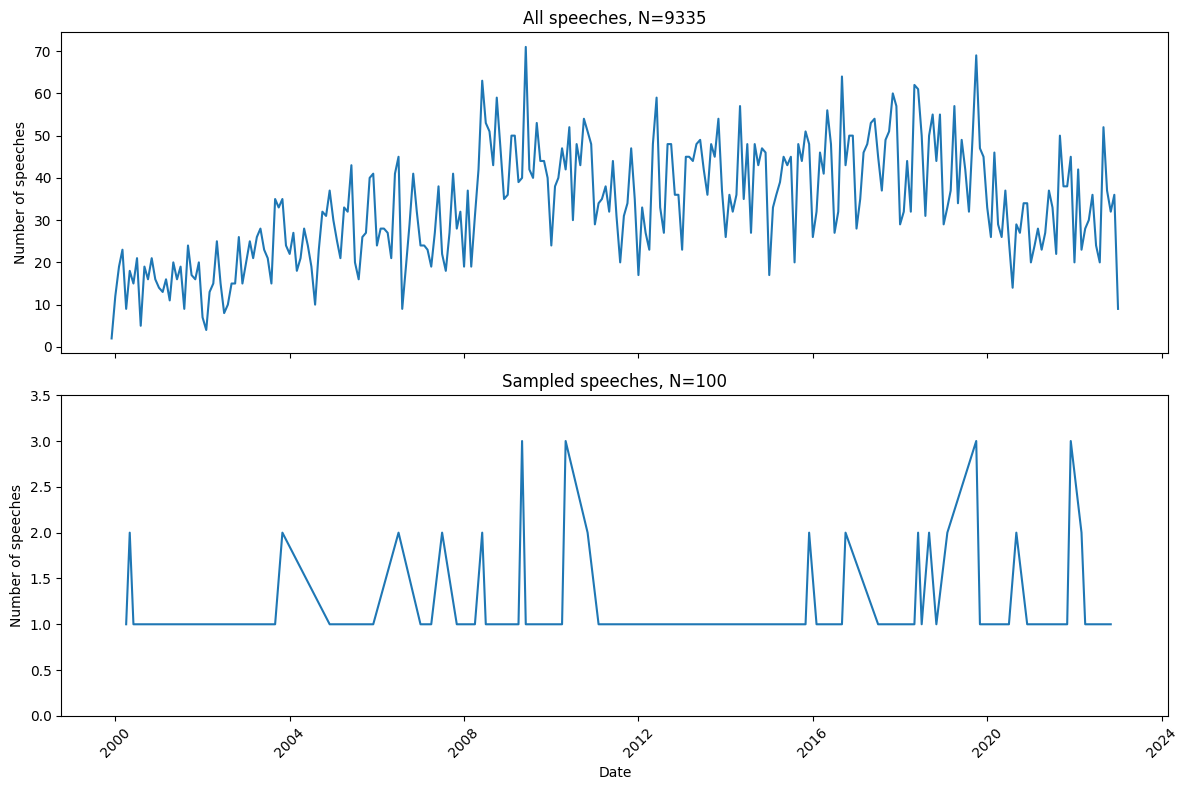

In [18]:
df_all = pd.DataFrame({
    "date": pd.to_datetime(all_set_dates)
})

df_sample = pd.DataFrame({
    "date": pd.to_datetime(sample_dates)
})

monthly_counts_all = (
    df_all
    .groupby(df_all["date"].dt.to_period("M"))
    .size()
    .reset_index(name="count")
)

monthly_counts_all_sampled = (
    df_sample
    .groupby(df_sample["date"].dt.to_period("M"))
    .size()
    .reset_index(name="count")
)

monthly_counts_all["date"] = monthly_counts_all["date"].dt.to_timestamp()
monthly_counts_all_sampled["date"] = monthly_counts_all_sampled["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    monthly_counts_all["date"],
    monthly_counts_all["count"]
)
axes[0].set_title(f"All speeches, N={len(all_set_dates)}")
axes[0].set_ylabel("Number of speeches")

axes[1].set_ylim(bottom=0, top=3.5)

axes[1].plot(
    monthly_counts_all_sampled["date"],
    monthly_counts_all_sampled["count"]
)
axes[1].set_title(f"Sampled speeches, N={len(sample_dates)}")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of speeches")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()